In [3]:
import numpy as np

# Create a random number generator with a seed value of 42
rng = np.random.default_rng(seed=42)

# Generate random numbers using this generator
random_numbers = rng.random(5)

print(random_numbers)

[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]


[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]

In [10]:
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt
from qiskit.dagcircuit import DAGCircuit, DAGOpNode, DAGInNode, DAGOutNode
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit import QuantumCircuit
from qiskit.transpiler.layout import Layout
from qiskit.transpiler import CouplingMap
from qiskit.transpiler.passes.layout.set_layout import SetLayout
from qiskit.transpiler.passes.layout.full_ancilla_allocation import FullAncillaAllocation
from qiskit.transpiler.passes.layout.enlarge_with_ancilla import EnlargeWithAncilla
from qiskit.transpiler.passes.layout.apply_layout import ApplyLayout
from qiskit.transpiler.passes.routing import SabreSwap
from qiskit.transpiler.passmanager import PassManager

import networkx as nx

from dac_part import remove_1q_and_consecutive_2q_gates_in_circuit
from collections import defaultdict
from dac_part import get_interaction_graph

from ag import qgrid, q20
import time
import os

In [11]:
def _layout_and_route_passmanager(initial_layout, coupling_map):
    layout_and_route = [
            SetLayout(initial_layout),
            FullAncillaAllocation(coupling_map),
            EnlargeWithAncilla(),
            ApplyLayout(),
            SabreSwap(coupling_map, heuristic = 'lookahead'),
        ]
    pm = PassManager(layout_and_route)
    return pm

def graph_of_circuit(circuit):
    ''' Return the interaction graph of the reduced QuantumCircuit C
            - node set: indices of qubits in C
            - edge set: all pair (p,q) if CNOT [p,q] or CNOT[q,p] in C
        Args:
            C (list): the input reduced circuit
        Returns:
            g (Graph)
    '''   
    g = nx.Graph()
    for gate in circuit:
        if gate.operation.name != 'cx': continue
        p, q = gate.qubits[0]._index, gate.qubits[1]._index
        g.add_edge(p,q)
    return g  

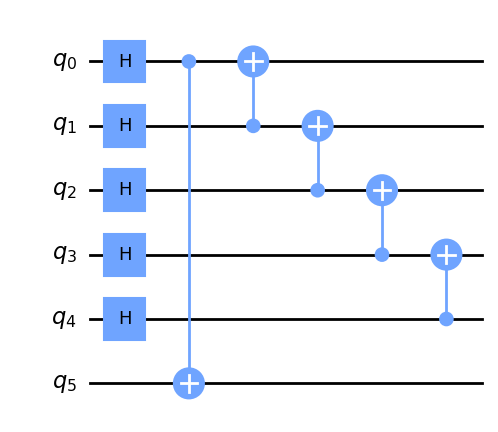

In [12]:
"""One artificial circuit example"""

qc = QuantumCircuit(6)
for idx in range(5):
   qc.h(idx)
   qc.cx(idx, (idx+5)%6)

qc.draw('mpl')

In [17]:
AG = qgrid(2,3)
coupling_map = CouplingMap(AG.edges())

physical_qubits = [3,5,2,1,0,4]
initial_layout = Layout({q: qc.qubits[i] for i, q in enumerate(physical_qubits)})
print(initial_layout)

pm = _layout_and_route_passmanager(initial_layout, coupling_map)
new_circ = pm.run(qc)
new_circ.draw()

Layout({
3: Qubit(QuantumRegister(6, 'q'), 0),
5: Qubit(QuantumRegister(6, 'q'), 1),
2: Qubit(QuantumRegister(6, 'q'), 2),
1: Qubit(QuantumRegister(6, 'q'), 3),
0: Qubit(QuantumRegister(6, 'q'), 4),
4: Qubit(QuantumRegister(6, 'q'), 5)
})


┌───┐                               
q_4 -> 0 ┤ H ├────────────────────────────■──
         ├───┤                          ┌─┴─┐
q_3 -> 1 ┤ H ├───────────────────────■──┤ X ├
         ├───┤                       │  └───┘
q_2 -> 2 ┤ H ├─X───■───X─────────────┼───────
         ├───┤ │   │   │           ┌─┴─┐     
q_0 -> 3 ┤ H ├─X───┼───┼────────■──┤ X ├─────
         └───┘   ┌─┴─┐ │ ┌───┐  │  └───┘     
q_5 -> 4 ────────┤ X ├─X─┤ X ├──┼────────────
         ┌───┐   └───┘   └─┬─┘┌─┴─┐          
q_1 -> 5 ┤ H ├─────────────■──┤ X ├──────────
         └───┘                └───┘

In [18]:
print(initial_layout._v2p)

{Qubit(QuantumRegister(6, 'q'), 0): 3, Qubit(QuantumRegister(6, 'q'), 1): 5, Qubit(QuantumRegister(6, 'q'), 2): 2, Qubit(QuantumRegister(6, 'q'), 3): 1, Qubit(QuantumRegister(6, 'q'), 4): 0, Qubit(QuantumRegister(6, 'q'), 5): 4}


In [19]:
print(initial_layout._p2v)

{3: Qubit(QuantumRegister(6, 'q'), 0), 5: Qubit(QuantumRegister(6, 'q'), 1), 2: Qubit(QuantumRegister(6, 'q'), 2), 1: Qubit(QuantumRegister(6, 'q'), 3), 0: Qubit(QuantumRegister(6, 'q'), 4), 4: Qubit(QuantumRegister(6, 'q'), 5)}


In [8]:
from qiskit import QuantumCircuit

path = '../bench/6Qbench/'
#filename = '6QBT_large_depth_opt_1_1.5_no.5.qasm'
filename = '6QBT_large_gate_opt1_1_1.5_no.8.qasm'
"""Create a QuantumCircuit from the QASM file"""
with open(path+filename, 'r') as file:
    qasm_code = file.read()
qc = QuantumCircuit.from_qasm_str(qasm_code)
qc.draw()
#circuit_drawer(qc, output='mpl')  # 'mpl' option for Matplotlib-based visualization

┌───┐          ┌───┐                    ┌───┐┌───┐┌───┐               »
q_0: ┤ H ├──────────┤ X ├───────■─────────■──┤ H ├┤ H ├┤ H ├───────────────»
     └───┘┌───┐┌───┐└─┬─┘┌───┐  │  ┌───┐  │  └───┘└───┘├───┤               »
q_1: ─────┤ X ├┤ H ├──┼──┤ H ├──┼──┤ H ├──┼─────────■──┤ H ├───────────────»
          └─┬─┘└───┘  │  └───┘  │  ├───┤  │  ┌───┐  │  └───┘               »
q_2: ───────┼─────────┼─────────┼──┤ X ├──┼──┤ H ├──┼──────────────■───────»
     ┌───┐  │  ┌───┐  │       ┌─┴─┐└─┬─┘┌─┴─┐└───┘  │  ┌───┐┌───┐  │  ┌───┐»
q_3: ┤ H ├──┼──┤ H ├──┼───────┤ X ├──┼──┤ X ├───────┼──┤ X ├┤ X ├──┼──┤ H ├»
     └───┘  │  ├───┤  │       └───┘  │  ├───┤┌───┐  │  └─┬─┘└─┬─┘  │  └───┘»
q_4: ───────■──┤ H ├──┼────■─────────■──┤ H ├┤ H ├──┼────┼────┼────┼───────»
               └───┘  │  ┌─┴─┐┌───┐┌───┐└───┘└───┘┌─┴─┐  │    │  ┌─┴─┐     »
q_5: ─────────────────■──┤ X ├┤ H ├┤ H ├──────────┤ X ├──■────■──┤ X ├─────»
                         └───┘└───┘└───┘          └───┘          └───┘     »
«          
«q_0: ──■──
«       │  
«q_1: ──┼──
«       │  
«q_2: ──┼──
«     ┌─┴─┐
«q_3: ┤ X ├
«     └───┘
«q_4: ─────
«          
«q_5: ─────
«